<a href="https://colab.research.google.com/github/yarolava/mn/blob/labwork/lab_works/lab_0/lab_0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab work #0
# Ярослава Наталіна
# КС31

# 1. Using Numpy

**Task 1.1**: Create a NumPy array containing the numbers from 1 to 10. Perform the following operations:
1. Find the sum of all elements in the array.
2. Find the mean of all elements in the array.
3. Find the maximum and minimum elements in the array.
4. Sort the array in ascending order.

In [18]:
import numpy as np

arr = np.arange(1, 11)
print("Array:", arr)
print("Sum:", np.sum(arr))
print("Mean:", np.mean(arr))
print("Max:", np.max(arr))
print("Min:", np.min(arr))
print("Sorted:", np.sort(arr))


Array: [ 1  2  3  4  5  6  7  8  9 10]
Sum: 55
Mean: 5.5
Max: 10
Min: 1
Sorted: [ 1  2  3  4  5  6  7  8  9 10]


**Task 1.2**: Create a 2x3 NumPy matrix containing the numbers from -10 to 10. Perform the following operations:
1. Find the transpose of the matrix.
2. Find the determinant of the matrix (It must throw an error for [non-square matrices](https://math.stackexchange.com/questions/854180/determinant-of-a-non-square-matrix)).
3. Multiply the matrix by a scalar (e.g., 2).
4. Add two matrices element-wise.

In [19]:
matrix = np.array([[-10, -5, 0], [5, 10, 15]])
print("Matrix:\n", matrix)


transpose = matrix.T
print("Transpose:\n", transpose)


try:
    det = np.linalg.det(matrix)
except np.linalg.LinAlgError as e:
    print("Error:", e)
except ValueError as e:
    print("Expected error (non-square matrix):", e)

print("Matrix * 2:\n", matrix * 2)


matrix2 = np.array([[1, 2, 3], [4, 5, 6]])
print("Element-wise sum:\n", matrix + matrix2)



Matrix:
 [[-10  -5   0]
 [  5  10  15]]
Transpose:
 [[-10   5]
 [ -5  10]
 [  0  15]]
Error: Last 2 dimensions of the array must be square
Matrix * 2:
 [[-20 -10   0]
 [ 10  20  30]]
Element-wise sum:
 [[-9 -3  3]
 [ 9 15 21]]


# 2. Using Pandas

**Task 2.1**: Data Loading and Inspection

Load the Iris dataset into a Pandas DataFrame and inspect the first few rows.

Steps:
1. Load the Iris dataset from a CSV file or directly from a URL.
2. Display the first 5 rows of the DataFrame using the head() method.
3. Use the info() method to get a concise summary of the DataFrame.

In [21]:
import pandas as pd
df = pd.read_csv("fisher_irises.csv")

print("First 5 rows:\n", df.head())
print("\nDataFrame info:\n")
df.info()



First 5 rows:
    sepal_length  sepal_width  petal_length  petal width target_class
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa

DataFrame info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  149 non-null    float64
 1   sepal_width   148 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal width   147 non-null    float64
 4   target_class  149 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


**Task 2.2**: Data Cleaning & Preprocessing

Handle missing values and ensure data types are appropriate.

Steps:
1. Check for any missing values in the DataFrame using isnull().sum().
2. If there are missing values, fill them with the mean of the respective column.
3. Convert any necessary columns to the appropriate data type (e.g., categorical to numerical).

In [31]:
print("Пропущені значення:\n", df.isnull().sum())

df.fillna(df.mean(numeric_only=True), inplace=True)

df['target_class'] = df['target_class'].astype('category')

df['class_code'] = df['target_class'].cat.codes
print(df.dtypes)



Пропущені значення:
 sepal_length    0
sepal_width     0
petal_length    0
petal width     0
target_class    1
dtype: int64
sepal_length     float64
sepal_width      float64
petal_length     float64
petal width      float64
target_class    category
class_code          int8
dtype: object


**Task 2.3**: Data Analysis

Perform basic statistical analysis on the dataset.

Steps:
1. Calculate the mean, median, and standard deviation of each numerical column.
2. Group the data by the 'species' column and calculate the mean of each numerical column for each species.
3. Use the describe() method to get a statistical summary of the DataFrame.

In [30]:
print("Середнє:\n", df.mean(numeric_only=True))

print("\nМедіана:\n", df.median(numeric_only=True))

print("\nСтандартне відхилення:\n", df.std(numeric_only=True))

print("\nСереднє по класах:\n", df.groupby('target_class').mean(numeric_only=True))

print("\nОписова статистика:\n", df.describe())



Середнє:
 sepal_length    5.829530
sepal_width     3.055405
petal_length    3.758667
petal width     1.182993
dtype: float64

Медіана:
 sepal_length    5.80
sepal_width     3.00
petal_length    4.35
petal width     1.30
dtype: float64

Стандартне відхилення:
 sepal_length    0.810626
sepal_width     0.433386
petal_length    1.764420
petal width     0.754972
dtype: float64

Середнє по класах:
                  sepal_length  sepal_width  petal_length  petal width
target_class                                                         
Iris-setosa          5.006000     3.418000      1.464000     0.244000
Iris-versicolor      5.936000     2.773108      4.260000     1.326000
Iris-virginica       6.523052     2.978682      5.528571     1.978551

Описова статистика:
        sepal_length  sepal_width  petal_length  petal width
count    150.000000   150.000000    150.000000   150.000000
mean       5.829530     3.055405      3.758667     1.182993
std        0.810626     0.433386      1.764420     0

**Task 2.4**: Data Visualization

Visualize the distribution of data using Pandas' built-in plotting capabilities.

Steps:
1. Create a histogram for each numerical column to visualize the distribution of data.
2. Create a box plot for each numerical column to identify any outliers.
3. Use a pair plot to visualize relationships between different numerical features.

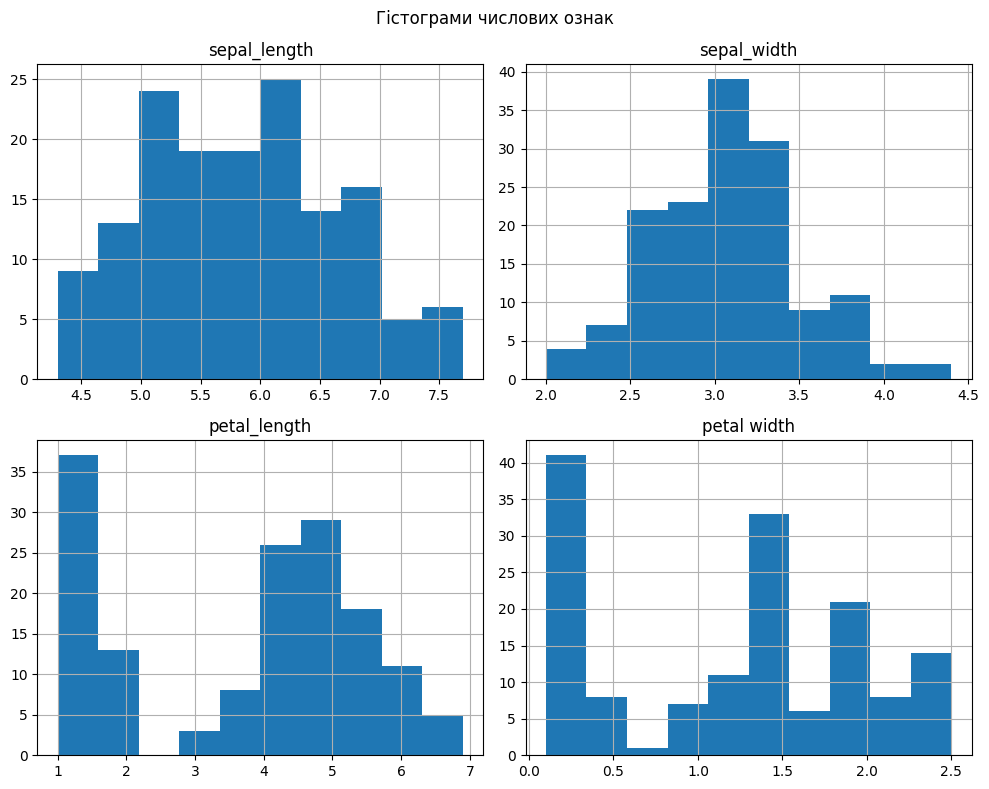

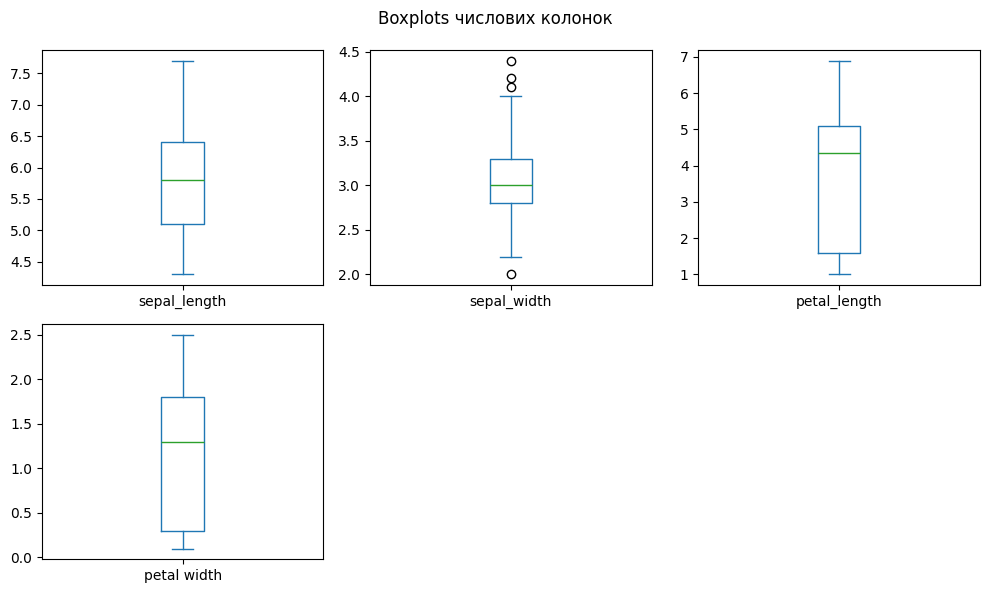

In [28]:


df.hist(figsize=(10, 8))
plt.suptitle("Гістограми числових ознак")
plt.tight_layout()
plt.show()

df.plot(kind='box', subplots=True, layout=(2,3), figsize=(10, 6), title="Boxplots числових колонок")
plt.tight_layout()
plt.show()




# 3. Using Matplotlib & Seaborn

**Task 3.1**: Basic Plotting with Matplotlib

Create basic plots to visualize the Iris dataset.

Steps:
1. Create a scatter plot of sepal_length vs. sepal_width using Matplotlib.
2. Color the points by species to visualize the separation between different classes.
3. Add titles, labels, and a legend to the plot.

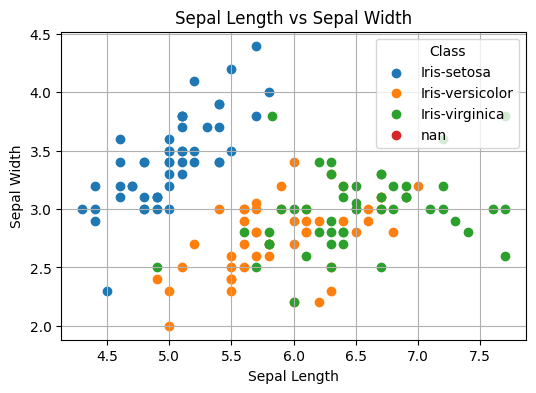

In [27]:
plt.figure(figsize=(6, 4))


for t_class in df['target_class'].unique():
    subset = df[df['target_class'] == t_class]
    plt.scatter(subset['sepal_length'], subset['sepal_width'], label=t_class)

plt.title('Sepal Length vs Sepal Width')
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.legend(title='Class')
plt.grid(True)
plt.show()



**Task 3.2**: Advanced Visualizations with Seaborn

Use Seaborn to create more complex and informative visualizations.

Steps:

1. Create a pair plot using Seaborn to visualize relationships between all pairs of features in the dataset.
2. Use different colors to represent different species in the pair plot.
3. Create a violin plot to visualize the distribution of petal_length for each species.

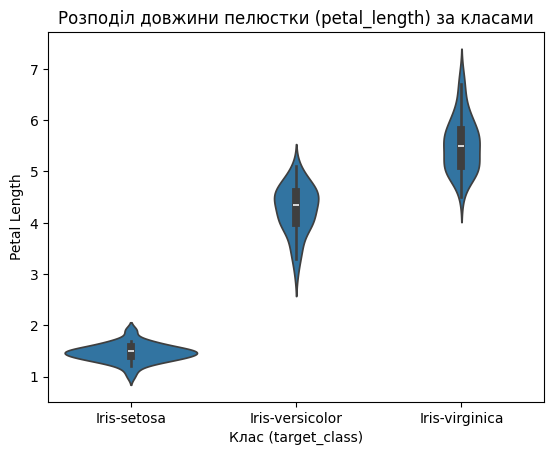

In [24]:
sns.violinplot(x='target_class', y='petal_length', data=df)
plt.title('Розподіл довжини пелюстки (petal_length) за класами')
plt.xlabel('Клас (target_class)')
plt.ylabel('Petal Length')
plt.show()



**Task 3.3**: Combining Matplotlib and Seaborn

Combine the strengths of Matplotlib and Seaborn to create customized visualizations.

Steps:

1. Create a heatmap using Seaborn to visualize the correlation matrix of the numerical features in the dataset.
2. Customize the heatmap by adjusting the color palette and adding annotations.
3. Use Matplotlib to add a title and adjust the layout of the heatmap for better readability.

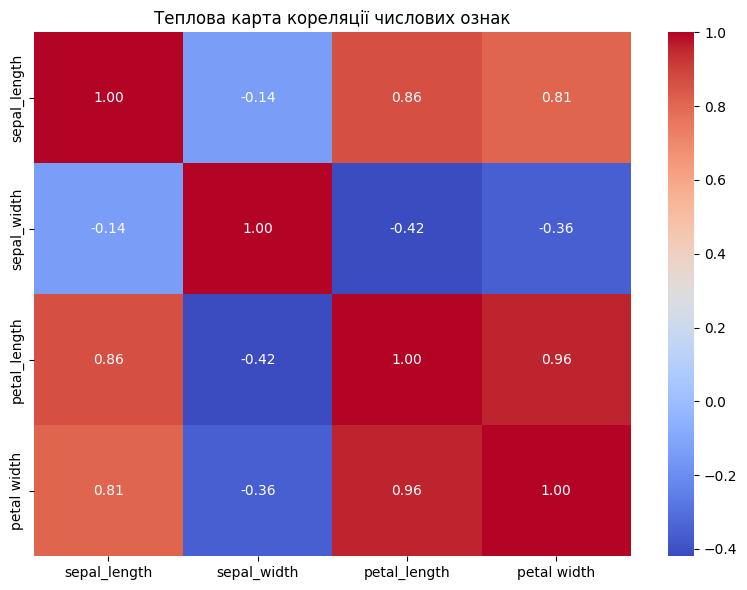

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include='number')

correlation = numeric_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Теплова карта кореляції числових ознак")
plt.tight_layout()
plt.show()



# BONUS TASK

**Bonus Task** Found a code for making __interactive__ 3D plots using `Plotly`

In [ ]:
# Your solution here
